In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Users\Victor\AppData\Local\Programs\Python\Python312\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Victor\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen impor

In [2]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [3]:
import torch
from scripts import *

In [4]:
import logging
from src.utils import configure_logger

logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

# Generating datasets

In [5]:
backend = "pennylane"  # "pennylane" | "qiskit" | "cirq"
target = "SRE"
method = "fwht"
output_dir = str(project_root) + "/outputs/data/training_data"
n_bins = 50
families = "random,haar,clifford,quansistor"
n_seeds = 175

In [6]:
print(output_dir)

C:\Users\victo\Desktop\University\Research\qml-quansistor-entropy\qqe/outputs/data/training_data


In [26]:
generate_dataset(
    backend=backend,
    target=target,
    method=method,
    use_dask=True,
    output_dir=output_dir,
    n_bins_option=n_bins,
    families=families,
    n_seeds_option=n_seeds,
    qubits_min=4,
    qubits_max=10,
    qubits_step=2,
    layers_min=2,
    layers_max=100,
    layers_step=2,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
)

2026-05-11 10:27:09,644 - src.GNN.dataset_builder - INFO - Processing family: random
2026-05-11 10:27:09,702 - src.GNN.dataset_builder - INFO - Generated 35000 configs for random
2026-05-11 10:27:10,101 - src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-11 10:27:10,752 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-05-11 10:27:10,778 - distributed.scheduler - INFO - State start
2026-05-11 10:27:10,797 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:58029
2026-05-11 10:27:10,799 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-05-11 10:27:10,800 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-11 10:27:10,875 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:58038'
2026-05-11 10:27:10,879 - distributed.nanny - INFO -      

SystemExit: 

c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [5]:
output_dir = str(project_root) + "/outputs/data/prediction_data"
n_bins = 50
families = "random,haar,clifford,quansistor"
n_seeds = 75

In [6]:
generate_pred_datasets(
    backend=backend,
    method="none",
    use_dask=True,
    output_dir=output_dir,
    n_bins_option=n_bins,
    families=families,
    n_seeds_option=n_seeds,
    qubits_min=12,
    qubits_max=30,
    qubits_step=2,
    layers_min=2,
    layers_max=100,
    layers_step=2,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
)

NameError: name 'backend' is not defined

# Training models

### GNN

In [28]:
model_type="gnn"
epochs = 25
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"

In [29]:
default_model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 2,
    "dropout_rate": 0.10,
}

default_train_hparams = {
    "weight_decay": 0.00003,
    "grad_clip": 0.04,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-11 14:32:34,349 - src.GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-05-11 14:32:34,361 - src.GNN.training.runners - INFO - Training configuration done.
2026-05-11 14:32:34,366 - src.GNN.training.runners - INFO - Collecting data paths...
2026-05-11 14:32:42,783 - src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-11 14:32:42,784 - src.GNN.training.runners - INFO - Data paths collected.
2026-05-11 14:32:42,784 - src.GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-05-11 14:35:09,075 - src.GNN.training.runners - INFO - Loaders and model built.
2026-05-11 14:35:09,077 - src.GNN.training.runners - INFO - Starting training...
2026-05-11 14:35:09,115 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Using device: cuda
Epoch 1/25:  53%|█████▎    | 427/804 [01:00<00:57,  6.53it/s, loss=0.6909, graphs=13696]

2026-05-11 14:36:09,162 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 428/804 | loss 0.690885 | elapsed 60.0s | graphs 13696


2026-05-11 14:37:01,953 - qqe.src.GNN.training.train - INFO - Training complete (112.8s) | running validation...


2026-05-11 14:37:13,446 - qqe.src.GNN.training.train - INFO - Losses | train 0.459330 | val 0.117254 | lr 1.00e-04 | time train=112.8s val=11.5s total=124.3s
2026-05-11 14:37:13,449 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-05-11 15:32:36,359 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 19 batch 469/804 | loss 0.048434 | elapsed 120.2s | graphs 15008


Epoch 19/25:  90%|█████████ | 725/804 [03:00<00:19,  4.15it/s, loss=0.0481, graphs=23232]

2026-05-11 15:33:36,468 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 19 batch 726/804 | loss 0.048077 | elapsed 180.4s | graphs 23232


2026-05-11 15:33:53,068 - qqe.src.GNN.training.train - INFO - Training complete (197.0s) | running validation...


2026-05-11 15:34:16,538 - qqe.src.GNN.training.train - INFO - Losses | train 0.047815 | val 0.036315 | lr 5.00e-05 | time train=197.0s val=23.5s total=220.4s
2026-05-11 15:34:16,539 - qqe.src.GNN.training.train - INFO - Early stopping at epoch 019 | best val 0.031610 | patience exhausted (10/10)
2026-05-11 15:35:21,586 - src.GNN.training.runners - INFO - Training complete.


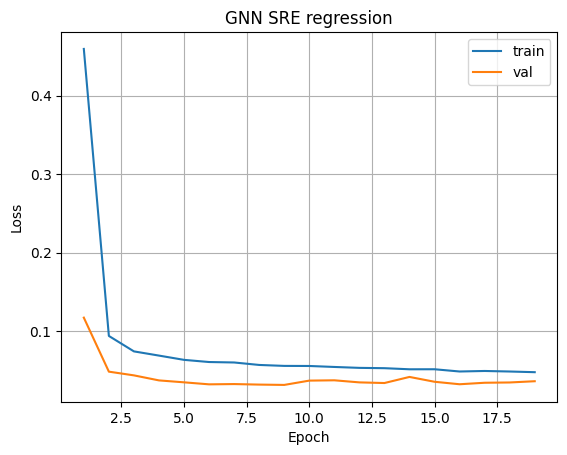

2026-05-11 15:35:21,994 - src.GNN.training.runners - INFO - Saved model checkpoint to ..\outputs\models\gnn_huber_random.pt
2026-05-11 15:35:22,003 - scripts.train_model - INFO - Final test loss: 0.031182


In [61]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_type=model_type,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=output_dir,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

### NN

In [62]:
model_type="nn"
epochs = 25
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"

In [63]:
default_model_hparams = {
    "hidden_dim": 128,
    "dropout_rate": 0.0,
}

default_train_hparams = {
    "weight_decay": 1e-3,
    "grad_clip": 5.0,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}

2026-05-11 15:36:24,358 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=nn | training_mode=per_family | family=random | loss_type=huber
2026-05-11 15:36:24,359 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-11 15:36:24,359 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-11 15:36:26,578 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-11 15:36:26,580 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-11 15:36:26,581 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=nn...
2026-05-11 15:37:33,618 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-11 15:37:33,619 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-11 15:37:33,622 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Using device: cuda
Epoch 1/25:  30%|██▉       | 238/804 [01:00<01:47,  5.24it/s, loss=0.6966, graphs=7648]

2026-05-11 15:38:33,679 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 239/804 | loss 0.696556 | elapsed 60.1s | graphs 7648


Epoch 1/25:  62%|██████▏   | 500/804 [02:00<00:56,  5.42it/s, loss=0.5178, graphs=16064]

2026-05-11 15:39:33,734 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 502/804 | loss 0.517793 | elapsed 120.1s | graphs 16064


...

2026-05-11 16:24:37,764 - qqe.src.GNN.training.train - INFO - Losses | train 0.027265 | val 0.029824 | lr 1.00e-04 | time train=79.3s val=8.7s total=88.0s
2026-05-11 16:24:37,765 - qqe.src.GNN.training.train - INFO - -------- EPOCH 025 --------


Epoch 25/25:  74%|███████▍  | 598/804 [01:00<00:23,  8.71it/s, loss=0.0276, graphs=19168]

2026-05-11 16:25:37,889 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 25 batch 599/804 | loss 0.027596 | elapsed 60.1s | graphs 19168


2026-05-11 16:25:58,136 - qqe.src.GNN.training.train - INFO - Training complete (80.4s) | running validation...


2026-05-11 16:26:05,815 - qqe.src.GNN.training.train - INFO - Losses | train 0.027740 | val 0.027818 | lr 5.00e-05 | time train=80.4s val=7.7s total=88.1s
2026-05-11 16:26:26,618 - qqe.src.GNN.training.runners - INFO - Training complete.


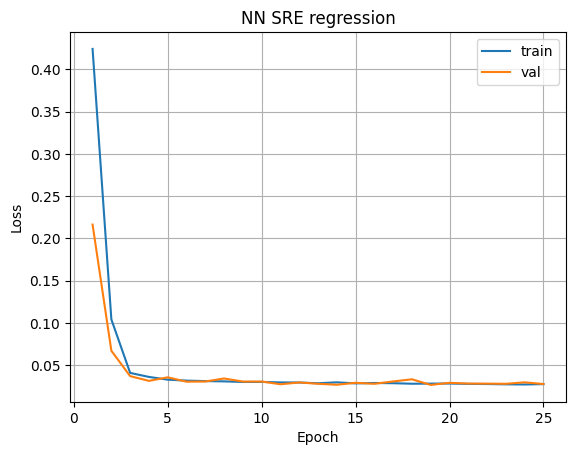

2026-05-11 16:26:26,821 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ..\outputs\models\nn_huber_random.pt
2026-05-11 16:26:26,825 - scripts.train_model - INFO - Final test loss: 0.026989


In [64]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_type=model_type,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=output_dir,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

In [65]:
model_type="regressor"
epochs = 25
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"

2026-05-11 16:27:16,971 - qqe.src.GNN.training.runners - INFO - Starting training | model_type=regressor | training_mode=per_family | family=random | loss_type=huber
2026-05-11 16:27:16,973 - qqe.src.GNN.training.runners - INFO - Training configuration done.
2026-05-11 16:27:16,974 - qqe.src.GNN.training.runners - INFO - Collecting data paths...
2026-05-11 16:27:17,377 - qqe.src.GNN.training.runners - INFO - Found 35700 data paths.
2026-05-11 16:27:17,378 - qqe.src.GNN.training.runners - INFO - Data paths collected.
2026-05-11 16:27:17,379 - qqe.src.GNN.training.runners - INFO - Building loaders and model for model_type=regressor...
2026-05-11 16:28:09,161 - qqe.src.GNN.training.runners - INFO - Loaders and model built.
2026-05-11 16:28:09,161 - qqe.src.GNN.training.runners - INFO - Starting training...
2026-05-11 16:28:09,164 - qqe.src.GNN.training.train - INFO - -------- EPOCH 001 --------


Using device: cuda
Epoch 1/25:  82%|████████▏ | 660/804 [01:00<00:14,  9.70it/s, loss=0.4117, graphs=21152]

2026-05-11 16:29:09,220 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 661/804 | loss 0.411716 | elapsed 60.1s | graphs 21152


2026-05-11 16:29:22,787 - qqe.src.GNN.training.train - INFO - Training complete (73.6s) | running validation...


2026-05-11 16:29:30,871 - qqe.src.GNN.training.train - INFO - Losses | train 0.381419 | val 0.237519 | lr 1.00e-04 | time train=73.6s val=8.1s total=81.7s
2026-05-11 16:29:30,873 - qqe.src.GNN.training.train - INFO - -------- EPOCH 002 --------


...

2026-05-11 16:58:22,236 - qqe.src.GNN.training.train - INFO - Losses | train 0.027491 | val 0.035022 | lr 1.00e-04 | time train=63.6s val=6.7s total=70.3s
2026-05-11 16:58:22,238 - qqe.src.GNN.training.train - INFO - -------- EPOCH 025 --------


Epoch 25/25:  96%|█████████▌| 772/804 [01:00<00:02, 13.11it/s, loss=0.0269, graphs=24736]

2026-05-11 16:59:22,266 - qqe.src.GNN.training.train - INFO - [Heartbeat] Epoch 25 batch 773/804 | loss 0.026898 | elapsed 60.0s | graphs 24736


2026-05-11 16:59:24,600 - qqe.src.GNN.training.train - INFO - Training complete (62.4s) | running validation...


2026-05-11 16:59:31,077 - qqe.src.GNN.training.train - INFO - Losses | train 0.026950 | val 0.026752 | lr 1.00e-04 | time train=62.4s val=6.5s total=68.8s
2026-05-11 16:59:50,793 - qqe.src.GNN.training.runners - INFO - Training complete.


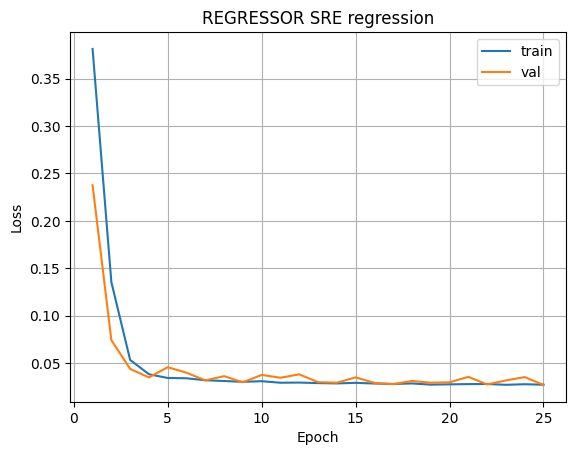

2026-05-11 16:59:50,927 - qqe.src.GNN.training.runners - INFO - Saved model checkpoint to ..\outputs\models\regressor_huber_random.pt
2026-05-11 16:59:50,930 - scripts.train_model - INFO - Final test loss: 0.027021


In [66]:
training(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    model_type=model_type,
    model_hparams=default_model_hparams,
    train_hparams=default_train_hparams,
    training_data_dir=output_dir,
    show_progress=True,
    show_val_progress=False,
    log_every_n_batches=10,
    heartbeat_secs=60.0,
    epoch_time_warning_secs=600.0,
)

## Optuna parameter search

### GNN

### NN

# Predictions

In [7]:
model_path="../outputs/models/nn_huber_random.pt"
model_kind="nn"
training_scope="family"
loss_type="huber"
model_family="random"
dataset_root="../data/"
dataset_family="random"
batch_size=32
global_feature_variant="binned"
node_feature_backend_variant=None
plot_n_layers=10
plot_n_qubits=10
split_by_family=True
show_progress=True

In [8]:
from qqe.src.experiments.plotting import (
    plot_fixed_layers_vary_qubits,
    plot_fixed_qubits_vary_layers,
)
from qqe.src.GNN.prediction.datasets import (
    build_loader,
    build_prediction_dataset,
    collect_prediction_paths,
)
from qqe.src.GNN.prediction.inference import predict
from qqe.src.GNN.prediction.model import build_model, checkpoint_path, load_checkpoint
from qqe.src.GNN.prediction.utils import save_predictions_csv
from qqe.src.utils import configure_logger

In [9]:
output_csv = f"../outputs/predictions/{training_scope}/{model_kind}_predictions_{model_family or 'global'}.csv"

state_dict, model_config, feature_config = load_checkpoint(model_path)

model = build_model(model_kind, model_config)
model.load_state_dict(state_dict, strict=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
dataset_root = ""

In [17]:
dataset_root = "../outputs/data/prediction_data"

In [19]:
pt_paths = collect_prediction_paths(dataset_root, "random")
if not pt_paths:
    raise RuntimeError("No prediction .pt files found.")

logger.info("Found %d prediction files", len(pt_paths))

..\outputs\data\prediction_data
..\outputs\data\prediction_data
[WindowsPath('../outputs/data/prediction_data/random/random_Q12_L100_S106832620.pt'), WindowsPath('../outputs/data/prediction_data/random/random_Q12_L100_S1081084085.pt'), WindowsPath('../outputs/data/prediction_data/random/random_Q12_L100_S1128053083.pt'), WindowsPath('../outputs/data/prediction_data/random/random_Q12_L100_S1158262582.pt'), WindowsPath('../outputs/data/prediction_data/random/random_Q12_L100_S1650763602.pt'), WindowsPath('../outputs/data/prediction_data/random/random_Q12_L100_S1681174828.pt'), WindowsPath('../outputs/data/prediction_data/random/random_Q12_L100_S1847421598.pt'), WindowsPath('../outputs/data/prediction_data/random/random_Q12_L100_S1931205154.pt'), WindowsPath('../outputs/data/prediction_data/random/random_Q12_L100_S2632970337.pt'), WindowsPath('../outputs/data/prediction_data/random/random_Q12_L100_S2767042605.pt'), WindowsPath('../outputs/data/prediction_data/random/random_Q12_L100_S2858692

2026-05-12 08:41:08,664 - __main__ - INFO - Found 12750 prediction files


In [ ]:
predictions(
    model_path="../outputs/models/nn_huber_random.pt",
    model_kind="nn",
    training_scope="family",
    loss_type="huber",
    model_family="random",
    dataset_root="../outputs/data",
    dataset_family="random",
    batch_size=32,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=10,
    plot_n_qubits=18,
    split_by_family=True,
    show_progress=True,
)

2026-05-12 08:43:01,962 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/nn_huber_random.pt
2026-05-12 08:43:05,315 - scripts.predictions - INFO - Found 12750 prediction files
Predicting (nn): 100%|██████████| 399/399 [00:22<00:00, 17.75batch/s]
2026-05-12 08:43:27,850 - scripts.predictions - INFO - Saved 12750 predictions to ../outputs/predictions/family/nn_predictions_random.csv
2026-05-12 08:43:28,019 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/nn_pred_layers_random.png
2026-05-12 08:43:28,022 - qqe.src.experiments.plotting - INFO - No predictions found for n_qubits=10
2026-05-12 08:43:28,022 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/nn_pred_qubits_random.png


In [26]:
predictions(
    model_path="../outputs/models/gnn_huber_random.pt",
    model_kind="gnn",
    training_scope="family",
    loss_type="huber",
    model_family="random",
    dataset_root="../outputs/data",
    dataset_family="random",
    batch_size=32,
    global_feature_variant="binned",
    node_feature_backend_variant=None,
    plot_n_layers=10,
    plot_n_qubits=18,
    split_by_family=True,
    show_progress=True,
)

2026-05-12 08:52:02,024 - scripts.predictions - INFO - Loading checkpoint: ../outputs/models/gnn_huber_random.pt
2026-05-12 08:52:05,253 - scripts.predictions - INFO - Found 12750 prediction files
Predicting (gnn): 100%|██████████| 399/399 [01:13<00:00,  5.41batch/s]
2026-05-12 08:53:20,070 - scripts.predictions - INFO - Saved 12750 predictions to ../outputs/predictions/family/gnn_predictions_random.csv
2026-05-12 08:53:20,202 - scripts.predictions - INFO - Saved fixed-layer plot to ../outputs/figures/predictions/family/gnn_pred_layers_random.png
2026-05-12 08:53:20,334 - scripts.predictions - INFO - Saved fixed-qubit plot to ../outputs/figures/predictions/family/gnn_pred_qubits_random.png
